## 实验6 MSTAR图像分类-使用卷积网络

### 读取图像形式的MSTAR数据
#划分为train/test  
#对数据进行归一化，即0-1之间，数据要变成float类型  
#把数据顺序打乱  
#注：若训练慢，可以减少训练图像数量

In [1]:
import torch
import numpy as np
import os
from PIL import Image

# 数据集路径
data_root = 'D:\DeepLearning\mstar'
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    for cls in class_names:
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(cls_dir, fname)
                img = Image.open(img_path).convert('L')
                img_array = np.array(img)
                images.append(img_array)
                labels.append(class_to_idx[cls])
    images = np.stack(images, axis=0)
    images = images[:, np.newaxis, :, :]   # (N, 1, H, W)
    labels = np.array(labels)
    return images, labels

# 加载训练集和验证集
train_img, train_lb = load_images_from_folder(train_dir)
val_img,   val_lb   = load_images_from_folder(val_dir)

print("总数据量：训练集 {} 张，验证集 {} 张".format(train_img.shape[0], val_img.shape[0]))

if train_lb.min() == 1:
    train_lb = train_lb - 1
    val_lb   = val_lb - 1

min_train_num = 2888
total_train = train_img.shape[0]
random_indices = np.random.choice(total_train, size=min(min_train_num, total_train), replace=False)
train_img = train_img[random_indices]
train_lb  = train_lb[random_indices]

# 归一化到 [0,1]
train_img = train_img / 255.0
val_img   = val_img   / 255.0

# 独热编码
num_classes = len(np.unique(train_lb))
one_hot_train_lb = np.eye(num_classes)[train_lb]
one_hot_val_lb   = np.eye(num_classes)[val_lb]

# 打印信息
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape, '热编码训练集标签格式为:', one_hot_train_lb.shape)
print('验证集图像格式为:', val_img.shape,   '验证集标签格式为:', val_lb.shape,   '热编码验证集标签格式为:', one_hot_val_lb.shape)

# 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

总数据量：训练集 2747 张，验证集 2425 张
训练集图像格式为: (2747, 1, 128, 128) 训练集标签格式为: (2747,) 热编码训练集标签格式为: (2747, 10)
验证集图像格式为: (2425, 1, 128, 128) 验证集标签格式为: (2425,) 热编码验证集标签格式为: (2425, 10)
Using device: cuda


### 数据增强
#from torchvision.transforms  包含的数据增强进行数据扩充。


#参考下面的例子  

In [2]:
from torchvision.transforms import v2
import torch

train_img_t = torch.tensor(train_img, dtype=torch.float32)
train_lb_t  = torch.tensor(train_lb,  dtype=torch.long)
val_img_t   = torch.tensor(val_img,   dtype=torch.float32)
val_lb_t    = torch.tensor(val_lb,    dtype=torch.long)

transform_aug = v2.Compose([
    # 几何变换
    v2.RandomRotation(degrees=(-15, 15)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomResizedCrop(size=(128, 128), scale=(0.85, 1.0), antialias=True),
    
    # 强度变换
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.GaussianBlur(kernel_size=3, sigma=(0.5, 1.0)),
])

augmented_img = transform_aug(train_img_t)
augmented_lb  = train_lb_t.clone()

train_img_aug = torch.cat([train_img_t, augmented_img], dim=0)
train_lb_aug  = torch.cat([train_lb_t,  augmented_lb],  dim=0)

### 题目1：定义并训练卷积神经网络（基于Pytorch）
#利用BN层、超参数调整等方式，提升分类精度。   

#### 定义网络  

In [3]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self, input_channels=1, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, 3, stride=1, padding=1) # 128x128
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)             # 64x64
        self.conv3 = nn.Conv2d(64, 128, 3, stride=1, padding=1)            # 64x64
        self.conv4 = nn.Conv2d(128, 128, 3, stride=2, padding=1)           # 32x32
        self.conv5 = nn.Conv2d(128, 256, 3, stride=1, padding=1)           # 32x32
        self.conv6 = nn.Conv2d(256, 256, 3, stride=2, padding=1)           # 16x16
        
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(128)
        self.bn5 = nn.BatchNorm2d(256)
        self.bn6 = nn.BatchNorm2d(256)
        
        self.relu = nn.ReLU()
        
        self.fc1 = nn.Linear(256 * 16 * 16, 1024)
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(1024, 128)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.relu(self.bn6(self.conv6(x)))
        
        x = x.view(x.size(0), -1)
        x = self.dropout1(self.relu(self.fc1(x)))
        x = self.dropout2(self.relu(self.fc2(x)))
        x = self.fc3(x)
        
        return x


#### 训练\测试网络

##### 定义训练函数和加载函数

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os
import matplotlib.pyplot as plt

def train_model(train_loader, val_loader, num_classes, device,
                epochs=15, learning_rate=0.0005, weight_decay=1e-4,
                save_dir='models', resume_from=None, verbose=True):
    """
    训练模型函数
    
    参数:
        train_loader: 训练数据加载器
        val_loader: 验证数据加载器
        num_classes: 类别数
        device: 计算设备
        epochs: 训练轮数
        learning_rate: 学习率
        weight_decay: 权重衰减
        save_dir: 模型保存目录
        resume_from: 恢复训练的checkpoint路径，None表示从头训练
        verbose: 是否打印详细信息
    
    返回:
        history: 包含训练历史的字典
        model: 训练好的模型
    """
    
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    # 创建模型
    model = NeuralNetwork(input_channels=1, num_classes=num_classes)
    model = model.to(device)
    
    # 损失函数和优化器
    loss_fn = nn.CrossEntropyLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # 初始化训练状态
    start_epoch = 0
    best_val_acc = 0
    best_model_state = None
    loss_his = []
    acc_his = []
    val_loss_his = []
    val_acc_his = []
    
    # 如果指定了恢复点，加载之前的训练状态
    if resume_from is not None and os.path.exists(resume_from):
        checkpoint = torch.load(resume_from, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_acc = checkpoint.get('best_val_acc', 0)
        loss_his = checkpoint.get('loss_his', [])
        acc_his = checkpoint.get('acc_his', [])
        val_loss_his = checkpoint.get('val_loss_his', [])
        val_acc_his = checkpoint.get('val_acc_his', [])
        
        if verbose:
            print(f"从 checkpoint 恢复训练，起始轮次: {start_epoch + 1}")
            print(f"之前的最佳验证精度: {best_val_acc*100:.2f}%")
    else:
        if verbose:
            print("从头开始训练")
    
    model.train()
    for epoch in range(start_epoch, epochs):
        train_loss = 0.0
        train_correct = 0
        total_train = 0
        
        # 训练阶段
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(pred, 1)
            total_train += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()
        
        avg_train_loss = train_loss / total_train
        train_acc = train_correct / total_train
        loss_his.append(avg_train_loss)
        acc_his.append(train_acc)
      
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        total_val = 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                
                pred_val = model(X_val)
                loss_val = loss_fn(pred_val, y_val)
                val_loss += loss_val.item() * X_val.size(0)
                _, pred_label = torch.max(pred_val, 1)
                total_val += y_val.size(0)
                val_correct += (pred_label == y_val).sum().item()
        
        avg_val_loss = val_loss / total_val
        val_acc = val_correct / total_val
        val_loss_his.append(avg_val_loss)
        val_acc_his.append(val_acc)
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, os.path.join(save_dir, 'best_model.pth'))
        
        # 保存 checkpoint（用于恢复训练）
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_acc,
            'loss_his': loss_his,
            'acc_his': acc_his,
            'val_loss_his': val_loss_his,
            'val_acc_his': val_acc_his
        }
        torch.save(checkpoint, os.path.join(save_dir, 'checkpoint.pth'))
        
        model.train()
        scheduler.step()
        
        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
    
    model.load_state_dict(torch.load(os.path.join(save_dir, 'best_model.pth'), map_location=device))
    
    if verbose:
        print(f"\n训练完成！最佳验证精度: {best_val_acc*100:.2f}%")
        print(f"最佳模型已保存到: {save_dir}/best_model.pth")
        print(f"Checkpoint 已保存到: {save_dir}/checkpoint.pth")
    
    history = {
        'train_loss': loss_his,
        'train_acc': acc_his,
        'val_loss': val_loss_his,
        'val_acc': val_acc_his,
        'best_val_acc': best_val_acc
    }
    
    return history, model


def load_model_for_inference(model_path, input_channels=1, num_classes=10, device='cpu'):
    """加载模型用于推理（不包含训练状态）"""
    model = NeuralNetwork(input_channels=input_channels, num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model


def plot_training_history(history):
    """绘制训练曲线"""
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

##### 使用训练函数

In [5]:
# ========== 准备数据加载器 ==========
batch_size = 180
train_loader = DataLoader(TensorDataset(train_img_aug, train_lb_aug), 
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_img_t, val_lb_t), 
                        batch_size=batch_size, shuffle=False)

# ========== 训练模式1：从头开始训练 ==========
history, model = train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    device=device,
    epochs=15,
    learning_rate=0.0005,
    save_dir='models',
    resume_from=None,  # None 表示从头训练
    verbose=True
)

# ========== 训练模式2：从 checkpoint 恢复训练 ==========
# ckpt = torch.load('models/checkpoint.pth')
# new_epochs = ckpt['epoch'] + 5

# history, model = train_model(
#     train_loader=train_loader,
#     val_loader=val_loader,
#     num_classes=num_classes,
#     device=device,
#     epochs=new_epochs,
#     learning_rate=0.0005,
#     save_dir='models',
#     resume_from='models/checkpoint.pth',  # 从之前保存的checkpoint恢复
#     verbose=True
# )

# ========== 单独加载模型进行推理（不训练时使用） ==========
# inference_model = load_model_for_inference(
#     model_path='models/best_model.pth',
#     input_channels=1,
#     num_classes=num_classes,
#     device=device
# )

从头开始训练
Epoch  1/15, Train Loss: 2.3070, Train Acc: 18.07%, Val Loss: 2.0528, Val Acc: 26.27%
Epoch  2/15, Train Loss: 1.6468, Train Acc: 38.59%, Val Loss: 1.5007, Val Acc: 47.42%
Epoch  3/15, Train Loss: 1.0554, Train Acc: 60.21%, Val Loss: 1.2475, Val Acc: 58.35%
Epoch  4/15, Train Loss: 0.6573, Train Acc: 75.61%, Val Loss: 0.4816, Val Acc: 83.59%
Epoch  5/15, Train Loss: 0.5107, Train Acc: 81.18%, Val Loss: 0.8876, Val Acc: 66.02%
Epoch  6/15, Train Loss: 0.3411, Train Acc: 87.84%, Val Loss: 0.3346, Val Acc: 88.58%
Epoch  7/15, Train Loss: 0.2634, Train Acc: 90.17%, Val Loss: 0.2261, Val Acc: 93.07%
Epoch  8/15, Train Loss: 0.1832, Train Acc: 93.90%, Val Loss: 0.1796, Val Acc: 94.31%
Epoch  9/15, Train Loss: 0.1484, Train Acc: 94.98%, Val Loss: 0.2734, Val Acc: 90.64%
Epoch 10/15, Train Loss: 0.1117, Train Acc: 96.34%, Val Loss: 0.1739, Val Acc: 94.10%
Epoch 11/15, Train Loss: 0.0849, Train Acc: 97.32%, Val Loss: 0.2020, Val Acc: 93.44%
Epoch 12/15, Train Loss: 0.0695, Train Acc: 98.

#### 实验结果与分析
#e.g.哪些策略提升了分类精度  

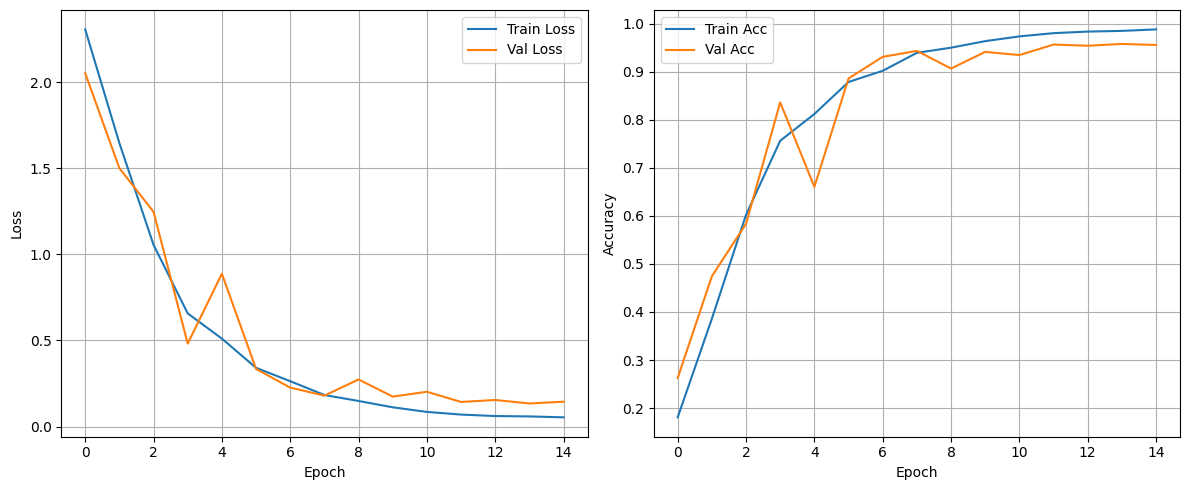

In [6]:
plot_training_history(history)

#### 总结

1. 设计了更复杂的数据增强：对训练图像进行了随机旋转、翻转、裁剪、亮度调整和高斯模糊，使训练样本翻倍，有效提升了模型泛化能力。   
2. 网络结构：设计了6层卷积（每层后加BN和ReLU）和3层全连接（中间层加Dropout），逐步提取图像特征并防止过拟合。
3. 训练策略：使用Adam优化器，学习率0.0005，余弦退火调度，训练15轮，保存验证精度最高的模型。
4. 结果分析：模型收敛较快，第12轮验证精度达到95.63%，最终最佳精度95.75%。训练损失持续下降至0.05，验证损失稳定在0.14~0.23之间，未出现过拟合。数据增强、BN和Dropout等策略共同作用，使模型在MSTAR数据集上取得了良好效果。

### 评分标准：
#测试精度越高，得分越高  
#只能提交PDF  
#代码尽量简洁高效，不包含实验题目无关的函数、代码  
#按照题目大纲编写程序  
#课上能够完成加分   
#实验结果完整、格式规范   
#图文并茂、实验结果分析有自己的想法   
##### 